In [36]:
# coding: utf-8
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)

def leaky_ReLU(x):
    return np.maximum(0.01*x, x)


def tanh(x):
    return np.tanh(x)

node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

np.random.seed(42)
def experiment(init_key, activation_key):
    for i in range(hidden_layer_size):
        
        x = np.random.randn(1000, 100)
        
        if i != 0:
            x = activations[i-1]
            
        initializer = initializers[init_key]
        activation_function = activation_functions[activation_key]
        w = initializer
        a = np.dot(x, w)

        z = activation_function(a)

        activations[i] = z

    # 히스토그램 그리기
    for i, a in activations.items():
        plt.subplot(1, len(activations), i+1)
        plt.title(str(i+1) + "-layer")
        if i != 0:
            plt.yticks([], [])
        # plt.xlim(0.1, 1)
        # plt.ylim(0, 7000)
        plt.hist(a.flatten(), 30, range=(-1, 1))

    plt.suptitle(f'{init_key}-{activation_key}')
    plt.savefig(f'{init_key}-{activation_key}.png')
    plt.show()


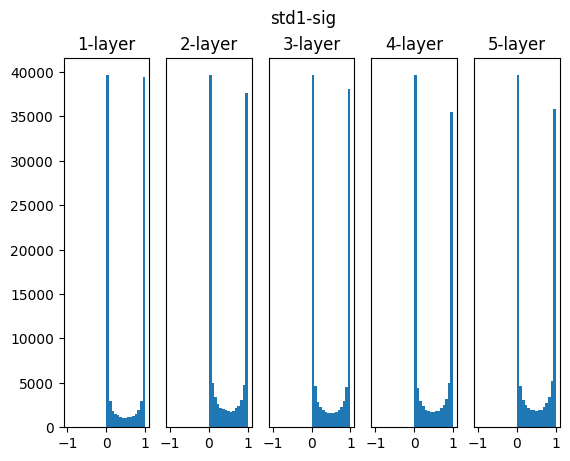

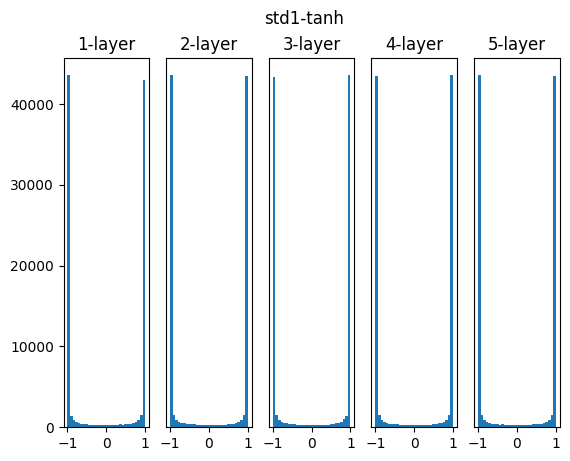

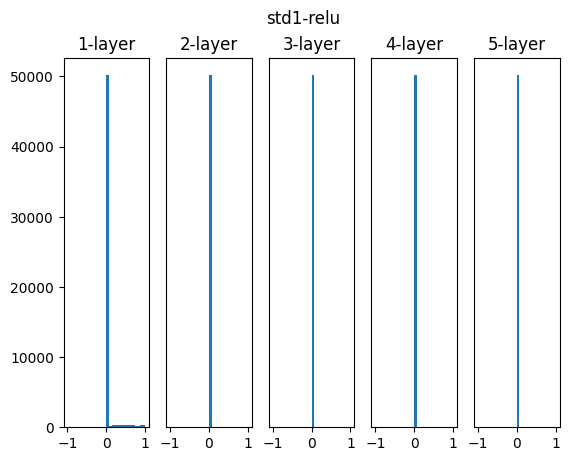

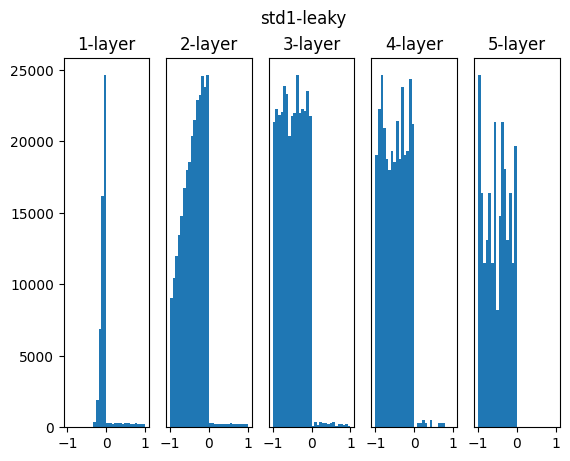

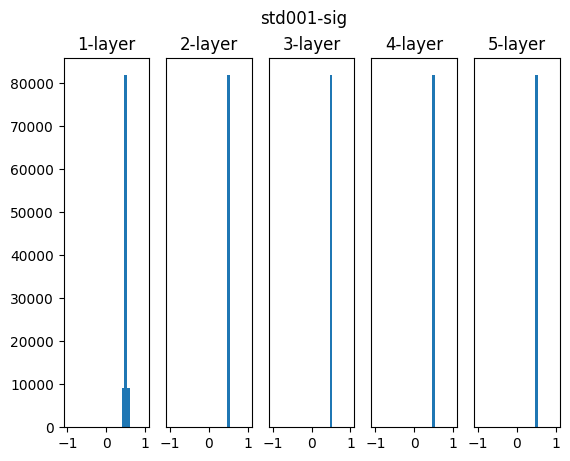

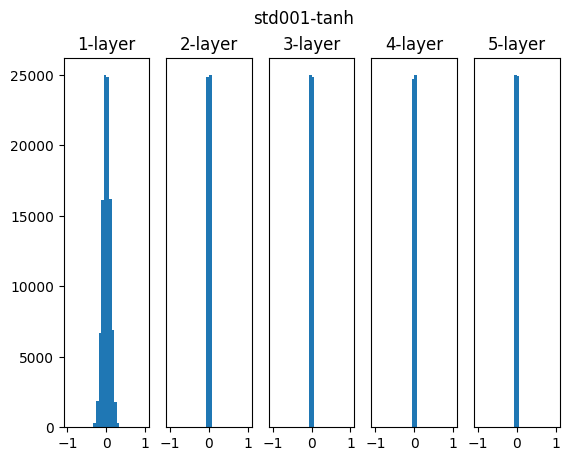

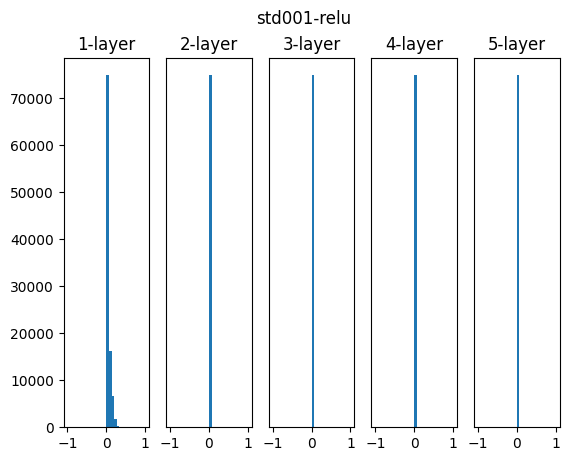

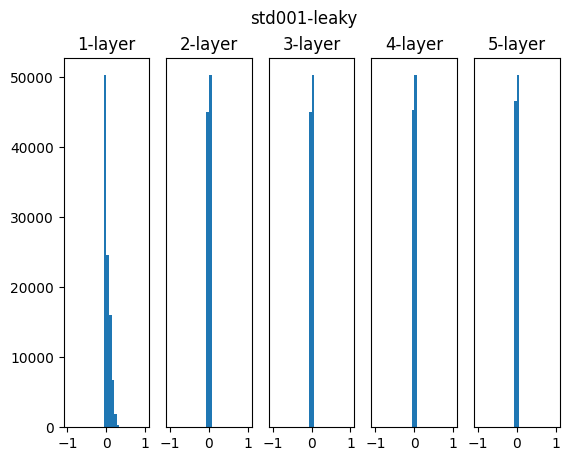

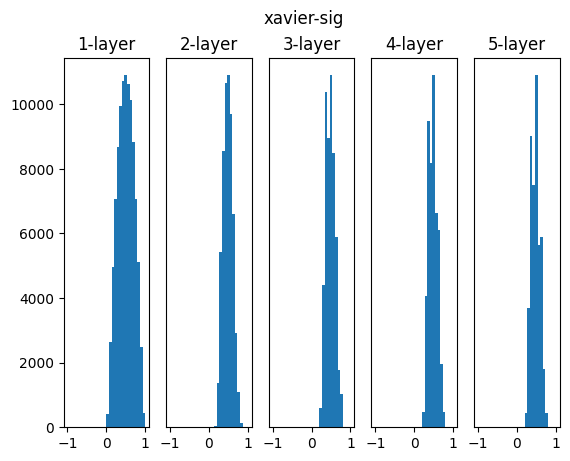

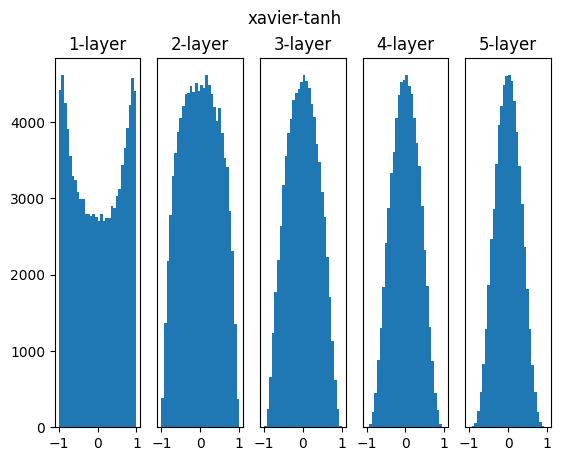

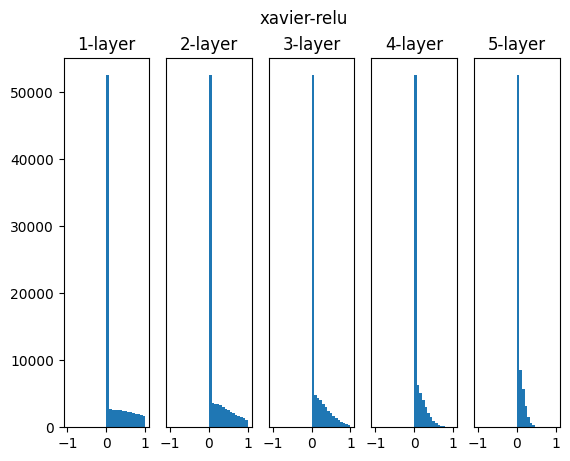

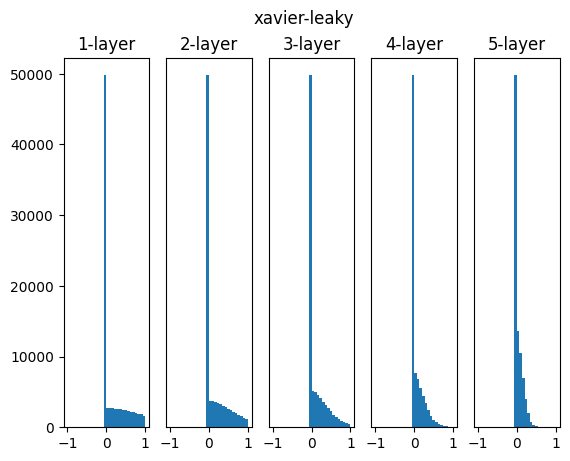

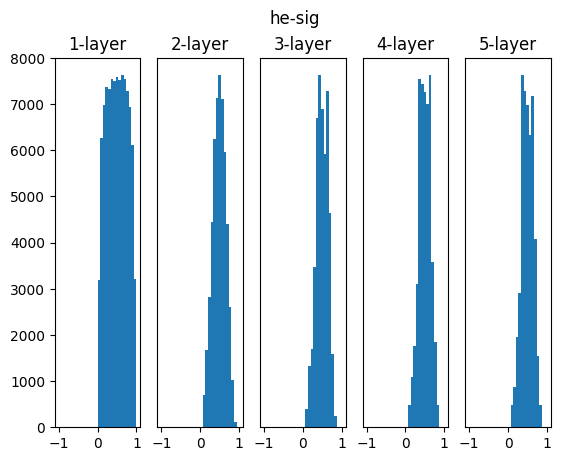

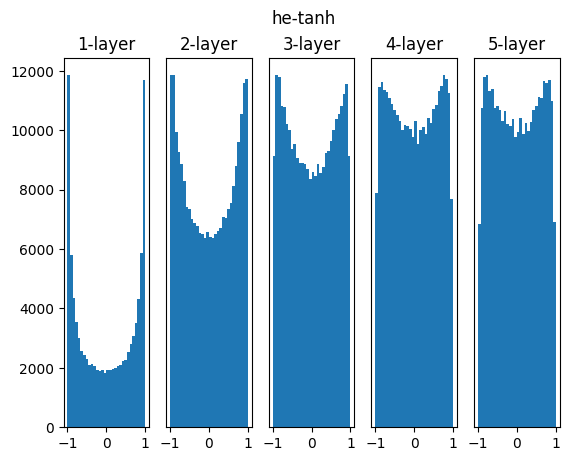

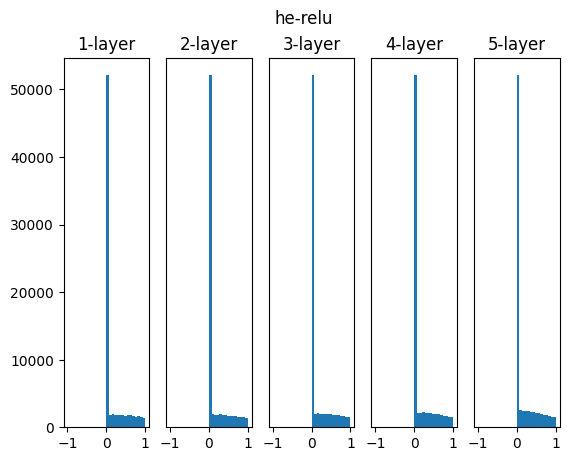

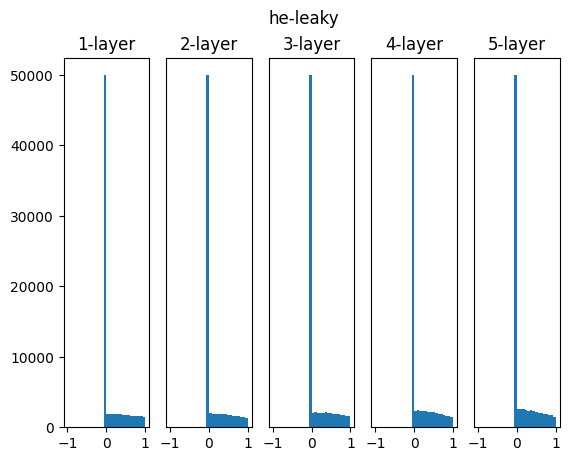

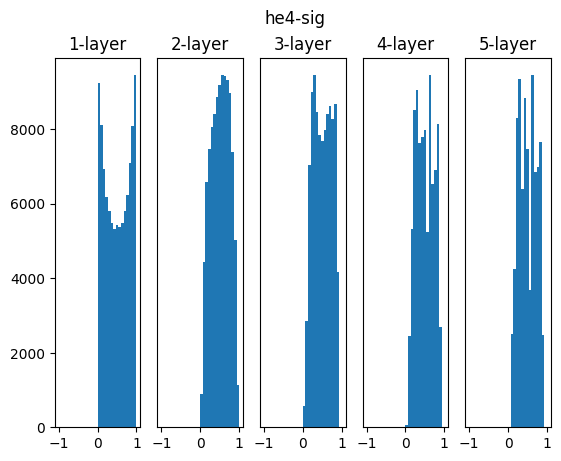

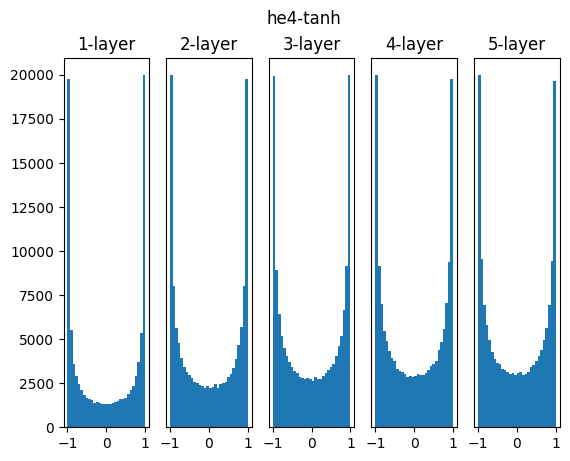

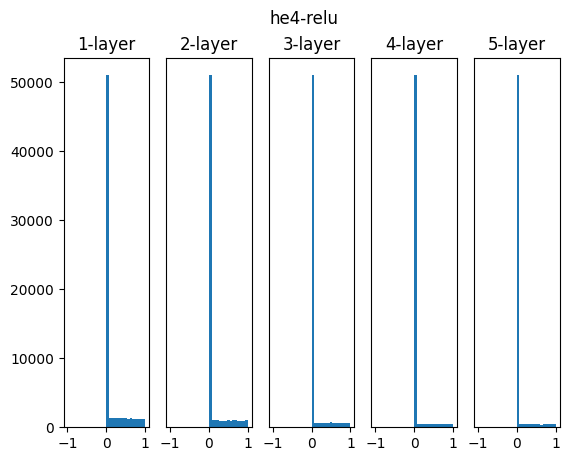

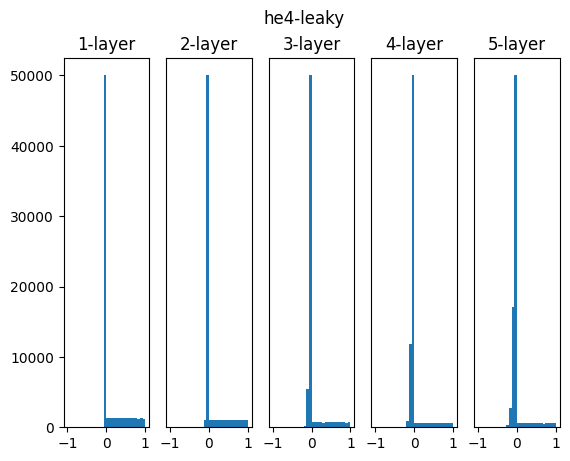

In [37]:
initializers = {'std1': np.random.randn(node_num, node_num) * 1,
                'std001': np.random.randn(node_num, node_num) * 0.01,
                'xavier': np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num),
                'he': np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num),
                'he4': np.random.randn(node_num, node_num) * np.sqrt(4.0 / node_num),
        }

activation_functions = {'sig':sigmoid,
                        'tanh':tanh,
                        'relu':ReLU,
                        'leaky':leaky_ReLU,
                        }



for initializer_key in initializers.keys():
        for activation_function_key in activation_functions.keys():
                experiment(initializer_key, activation_function_key)